In [1]:
import pandas as pd

# For pandas ≥1.3.0, use `on_bad_lines='skip'`
df1 = pd.read_csv("attributions_summary_1_2000.csv", on_bad_lines='skip')
df2 = pd.read_csv("attributions_summary_2001_None.csv", on_bad_lines='skip')

# Merge
df = pd.concat([df1, df2], ignore_index=True)

# Save
df.to_csv("attributions_summary_combined.csv", index=False)

print(df.columns.tolist())

['Score', 'Source', 'QA_ID', 'Extracted_Answer', 'Raw_Response']


In [2]:
import pandas as pd

# --- Step 1: Load the CSV ---
# df = pd.read_csv("your_summary_file.csv")  # Uncomment if needed

# --- Step 2: Drop any QA_IDs with "Error" ---
df = df[~df["QA_ID"].astype(str).str.contains("ERROR", na=False)]

# --- Step 3: Coerce Score column to numeric ---
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

# --- Step 4: Group and aggregate ---
grouped_stats = df.groupby("QA_ID").agg(
    Mean_Score=("Score", "mean"),
    Std_Score=("Score", "std"),
    Extracted_Answer=("Extracted_Answer", lambda x: x.dropna().astype(str).iloc[0] if not x.dropna().empty else None)
).reset_index()

# --- Step 5: Show results ---
print(grouped_stats.head(30))
print(f"✅ Total grouped QA_IDs (after dropping 'Error'): {len(grouped_stats)}")


          QA_ID  Mean_Score  Std_Score Extracted_Answer
0      Merge Q1    1.733053   7.755508                D
1     Merge Q10    1.425388   5.932218                C
2    Merge Q100    0.425521   0.604824                D
3   Merge Q1000    0.676062   2.004017                C
4   Merge Q1001    1.502042   3.288732                D
5   Merge Q1002    1.383422   2.282447                A
6   Merge Q1003    1.717320   2.806263                A
7   Merge Q1004    0.599098   0.433405                A
8   Merge Q1005    1.240978   3.028943                B
9   Merge Q1006    1.291072   3.416081                D
10  Merge Q1007    0.589089   1.954705                B
11  Merge Q1008   -0.002131   1.203938                B
12  Merge Q1009    1.377675   1.432245                A
13   Merge Q101    0.005960   0.303259                B
14  Merge Q1010    0.255151   1.261201                C
15  Merge Q1011    0.721906   3.495244                C
16  Merge Q1012    2.497318   4.965983          

In [3]:
# --- Step 5: Add upper and lower threshold columns ---
grouped_stats["Upper_Threshold"] = grouped_stats["Mean_Score"] + grouped_stats["Std_Score"]
grouped_stats["Lower_Threshold"] = grouped_stats["Mean_Score"] - grouped_stats["Std_Score"]

# --- Step 6: Display the updated DataFrame ---
grouped_stats.head(25)


,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Upper_Threshold,Lower_Threshold
0,Merge Q1,1.733053,7.755508,D,9.488561,-6.022455
1,Merge Q10,1.425388,5.932218,C,7.357607,-4.506830
2,Merge Q100,0.425521,0.604824,D,1.030345,-0.179303
3,Merge Q1000,0.676062,2.004017,C,2.680079,-1.327955
4,Merge Q1001,1.502042,3.288732,D,4.790774,-1.786689
5,Merge Q1002,1.383422,2.282447,A,3.665869,-0.899025
6,Merge Q1003,1.717320,2.806263,A,4.523583,-1.088943
7,Merge Q1004,0.599098,0.433405,A,1.032503,0.165693
8,Merge Q1005,1.240978,3.028943,B,4.269921,-1.787965
9,Merge Q1006,1.291072,3.416081,D,4.707153,-2.125009


In [4]:
import pandas as pd

# --- Step 1: Initialize columns ---
grouped_stats["Highly Relevant"] = 0
grouped_stats["Low Relevant"] = 0
grouped_stats["Irrelevant"] = 0

# --- Step 2: Assign relevance counts per QA_ID ---
for i, row in grouped_stats.iterrows():
    qa_id = row["QA_ID"]
    qa_rows = df[df["QA_ID"] == qa_id]

    if "Score" not in qa_rows.columns:
        print(f"⚠️ Skipped QA_ID {qa_id} — 'Score' column not found.")
        continue

    scores = qa_rows["Score"]

    high_count = (scores > row["Upper_Threshold"]).sum()
    low_count  = ((scores > row["Lower_Threshold"]) & (scores <= row["Upper_Threshold"])).sum()
    irr_count  = (scores <= row["Lower_Threshold"]).sum()

    grouped_stats.at[i, "Highly Relevant"] = high_count
    grouped_stats.at[i, "Low Relevant"] = low_count
    grouped_stats.at[i, "Irrelevant"] = irr_count


# --- Step 3: Normalize to 0–1 scale ---
relevance_cols = ["Highly Relevant", "Low Relevant", "Irrelevant"]
grouped_stats["total_relevance"] = grouped_stats[relevance_cols].sum(axis=1)

# Avoid divide-by-zero
for col in relevance_cols:
    grouped_stats[col] = grouped_stats[col] / grouped_stats["total_relevance"].replace(0, 1)

# Optional cleanup
grouped_stats.drop(columns=["total_relevance"], inplace=True)

# --- Step 4: Preview ---
grouped_stats.head(500)


,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Upper_Threshold,Lower_Threshold,Highly Relevant,Low Relevant,Irrelevant
0,Merge Q1,1.733053,7.755508,D,9.488561,-6.022455,0.142857,0.857143,0.000000
1,Merge Q10,1.425388,5.932218,C,7.357607,-4.506830,0.076923,0.923077,0.000000
2,Merge Q100,0.425521,0.604824,D,1.030345,-0.179303,0.090909,0.818182,0.090909
3,Merge Q1000,0.676062,2.004017,C,2.680079,-1.327955,0.181818,0.818182,0.000000
4,Merge Q1001,1.502042,3.288732,D,4.790774,-1.786689,0.090909,0.818182,0.090909
...,...,...,...,...,...,...,...,...,...
495,Merge Q1444,-0.269767,0.397228,D,0.127461,-0.666995,0.000000,0.666667,0.333333
496,Merge Q1445,15.989589,15.539375,B,31.528964,0.450214,0.200000,0.600000,0.200000
497,Merge Q1446,3.946168,NaN,H,NaN,NaN,0.000000,0.000000,0.000000
498,Merge Q1447,10.613080,7.748698,F,18.361777,2.864382,0.250000,0.625000,0.125000


## Measure Statistical Significance

In [30]:
print(grouped_stats[["Highly Relevant", "Low Relevant", "Irrelevant"]].describe())


       Highly Relevant  Low Relevant   Irrelevant
count      4045.000000   4045.000000  4045.000000
mean          0.137277      0.747650     0.090351
std           0.094244      0.183658     0.117015
min           0.000000      0.000000     0.000000
25%           0.076923      0.666667     0.000000
50%           0.142857      0.750000     0.071429
75%           0.200000      0.857143     0.153846
max           0.400000      1.000000     1.000000


In [31]:
from statsmodels.formula.api import ols
import statsmodels.api as sm  # Needed for sm.stats.anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# Filter out degenerate rows where no relevance was recorded
valid_stats = grouped_stats[
    (grouped_stats[["Highly Relevant", "Low Relevant", "Irrelevant"]].sum(axis=1) > 0)
].copy()

# Then re-run the reshaping and ANOVA
df_long = valid_stats[["Highly Relevant", "Low Relevant", "Irrelevant"]].reset_index().melt(
    id_vars="index",
    var_name="RelevanceCategory",
    value_name="Proportion"
)
df_long = df_long.rename(columns={"index": "Subject"})

# Refit the model
model = ols("Proportion ~ C(RelevanceCategory) + C(Subject)", data=df_long).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

# Tukey test
tukey = pairwise_tukeyhsd(
    endog=df_long["Proportion"],
    groups=df_long["RelevanceCategory"],
    alpha=0.05
)
print(tukey)


                            sum_sq      df             F  PR(>F)
C(RelevanceCategory)  1.115409e+03     2.0  2.624636e+04     0.0
C(Subject)            8.247184e-26  3944.0  9.840875e-28     1.0
Residual              1.676108e+02  7888.0           NaN     NaN
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1        group2    meandiff p-adj  lower   upper  reject
------------------------------------------------------------------
Highly Relevant   Irrelevant  -0.0481   0.0 -0.0544 -0.0418   True
Highly Relevant Low Relevant   0.6258   0.0  0.6196  0.6321   True
     Irrelevant Low Relevant    0.674   0.0  0.6677  0.6802   True
------------------------------------------------------------------


In [32]:
# --- Step 1: Compute overall mean and standard deviation of Mean_Score ---
overall_std = grouped_stats["Mean_Score"].std()
overall_mean = grouped_stats["Mean_Score"].mean()

# --- Step 2: Display results ---
print(f"Standard Deviation of Mean_Score: {overall_std:.4f}")
print(f"Mean of Mean_Score: {overall_mean:.4f}")


Standard Deviation of Mean_Score: 9.9933
Mean of Mean_Score: 4.5943


/tmp/ipykernel_1799208/2699468833.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=labels, widths=0.6, boxprops=boxprops)


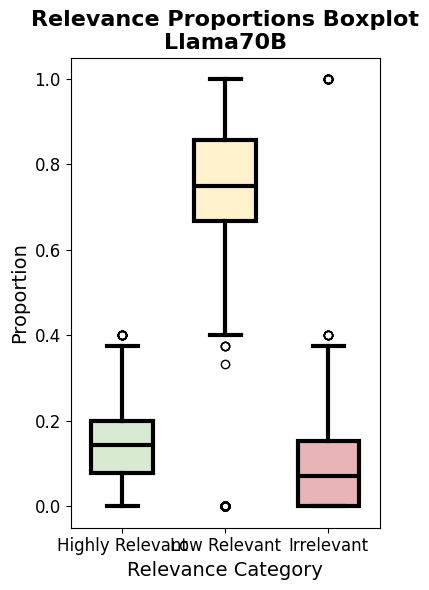

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Define custom HEX colors for categories ---
color_high = "#d9ead3"    # Green for Highly Relevant
color_low = "#fff2cc"     # Yellow for Low Relevant
color_irrel = "#e8b4b8"   # Pink/Red for Irrelevant

# --- Step 2: Prepare data for boxplot ---
data = [
    grouped_stats["Highly Relevant"].dropna(),
    grouped_stats["Low Relevant"].dropna(),
    grouped_stats["Irrelevant"].dropna()
]

labels = ["Highly Relevant", "Low Relevant", "Irrelevant"]
colors = [color_high, color_low, color_irrel]

# --- Step 3: Create and style the boxplot ---
fig, ax = plt.subplots(figsize=(4, 6))

boxprops = dict(linewidth=3)
bp = ax.boxplot(data, patch_artist=True, labels=labels, widths=0.6, boxprops=boxprops)

# Apply custom colors and styling
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

for element in ['whiskers', 'caps', 'medians']:
    for line in bp[element]:
        line.set_linewidth(3)
        
for median in bp['medians']:
    median.set_color("black")

# --- Step 4: Set axis labels, title, and aesthetics ---
ax.set_title("Relevance Proportions Boxplot\nLlama70B", fontsize=16, weight='bold')
ax.set_ylabel("Proportion", fontsize=14)
ax.set_xlabel("Relevance Category", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

# --- Step 5: Layout and save figure ---
plt.tight_layout()
plt.savefig("llama70b_relevance_boxplot_final.pdf", dpi=300)
plt.show()


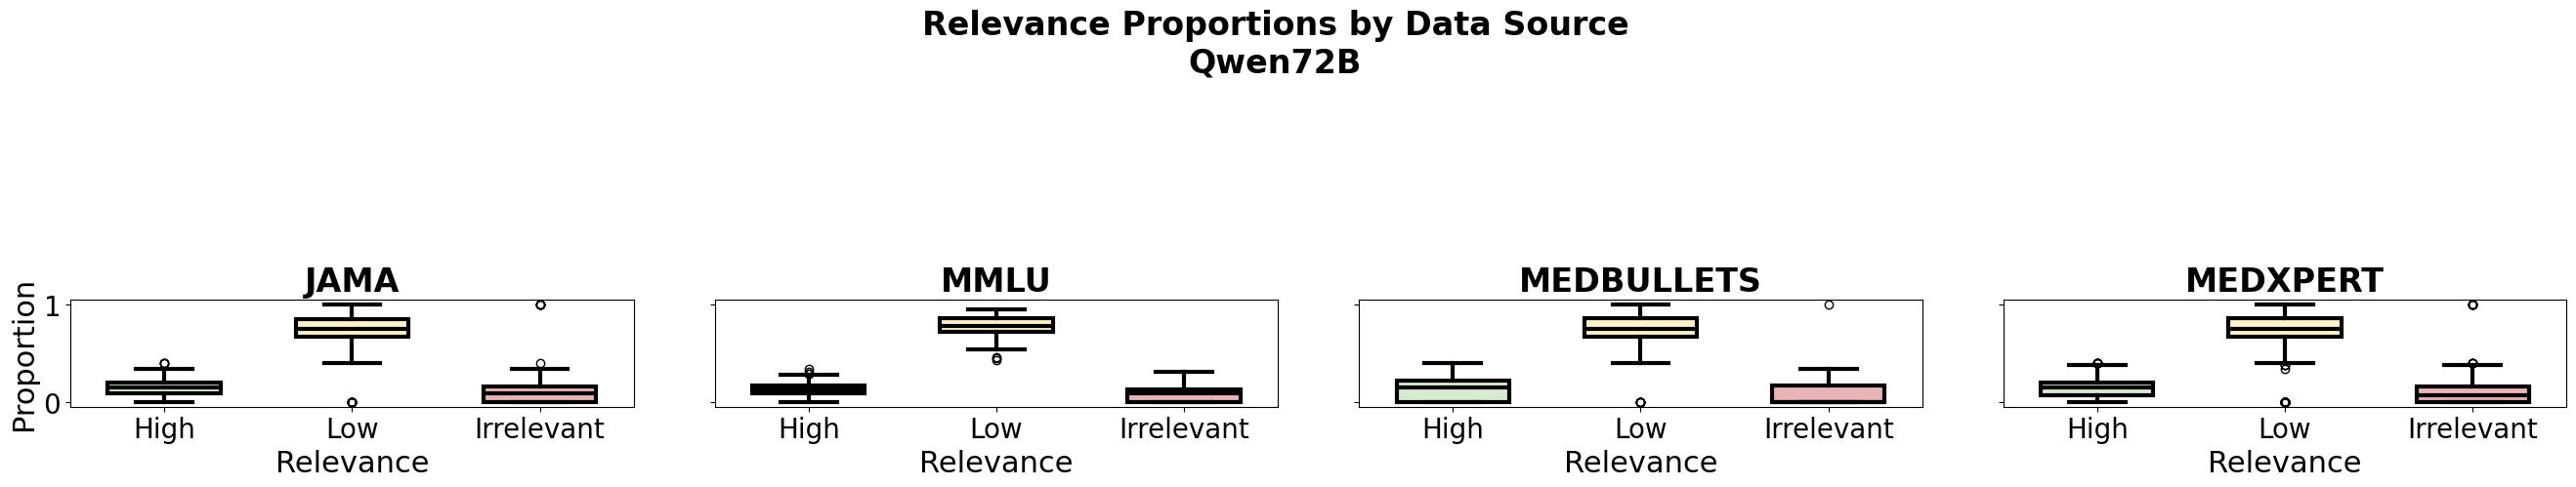

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Load ground truth file and align data sources ---
truth_df = pd.read_csv("merged_llm_4k_questions_with_QA_ID.csv")
grouped_stats["data_source"] = truth_df.loc[grouped_stats.index, "data_source"].values

# --- Step 2: Define color scheme and labels ---
color_high = "#d9ead3"    # Green for Highly Relevant
color_low = "#fff2cc"     # Yellow for Low Relevant
color_irrel = "#e8b4b8"   # Pink/Red for Irrelevant
colors = [color_high, color_low, color_irrel]
labels = ["High", "Low", "Irrelevant"]

# --- Step 3: Specify data sources ---
sources = ["jama", "mmlu", "medbullets", "medxpert"]

# --- Step 4: Create a row of boxplots ---
fig, axes = plt.subplots(1, 4, figsize=(28, 6), sharey=True)
plt.subplots_adjust(wspace=0.3)  # Wider spacing between plots


for i, source in enumerate(sources):
    ax = axes[i]
    subset = grouped_stats[grouped_stats["data_source"] == source]

    data = [
        subset["Highly Relevant"].dropna(),
        subset["Low Relevant"].dropna(),
        subset["Irrelevant"].dropna()
    ]

    bp = ax.boxplot(data, patch_artist=True, tick_labels=labels, widths=0.6)

    # Set box colors and line widths
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_linewidth(3)

    for element in ['whiskers', 'caps', 'medians']:
        for line in bp[element]:
            line.set_linewidth(3)
    for median in bp['medians']:
        median.set_color("black")

    # Axis titles and styles
    ax.set_title(source.upper(), fontsize=24, weight='bold')
    ax.set_xlabel("Relevance", fontsize=22)
    ax.tick_params(axis='both', labelsize=20)

# --- Step 5: Set common y-axis label and figure title ---
axes[0].set_ylabel("Proportion", fontsize=22)
plt.suptitle("Relevance Proportions by Data Source\nQwen72B", fontsize=24, weight='bold')

# --- Step 6: Final layout adjustments and save ---
plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig("relevance_proportions_boxplot_4sources.pdf", dpi=300)
plt.show()


## Compare the Results

In [44]:
import pandas as pd

# Load the CSV
correct_df = pd.read_csv("merged_llm_4k_questions_corrected.csv")

# Add QA_ID column in format "Merge Q1", "Merge Q2", ...
correct_df["QA_ID"] = ["Merge Q" + str(i + 1) for i in range(len(correct_df))]

# Optional: Save with new QA_ID
correct_df.to_csv("merged_llm_4k_questions_corrected_with_QA_ID.csv", index=False)
print(len(correct_df))


4054


In [48]:
import pandas as pd

# Step 1: Load both files
# df = pd.read_csv("qwen_72b_answers_summary.csv")           # predictions
truth_df = pd.read_csv("merged_llm_4k_questions_with_QA_ID.csv")  # ground truth

# Step 2: Create artificial QA_ID for row alignment
truth_df = truth_df.reset_index()  # index starts from 0
truth_df["QA_ID"] = "Merge Q" + (truth_df["index"] + 1).astype(str)

# Step 3: Standardize formats
df["Extracted_Answer"] = df["Extracted_Answer"].astype(str).str.strip().str.upper()
truth_df["answer_idx"] = truth_df["answer"].astype(str).str.strip().str.upper()

# ✅ Step 4: Drop duplicate QA_IDs in predictions
df = df.drop_duplicates(subset=["QA_ID"], keep="first")

# Step 5: Merge using QA_ID
merged = pd.merge(df, truth_df[["QA_ID", "answer_idx", "data_source"]], on="QA_ID", how="inner")

# Step 6: Compare predictions to ground truth
merged["match"] = merged.apply(
    lambda row: "Correct" if row["Extracted_Answer"] == row["answer_idx"] else "Incorrect",
    axis=1
)

# Step 7: Compute and print accuracy
correct_count = (merged["match"] == "Correct").sum()
total_count = merged["match"].notna().sum()
accuracy = correct_count / total_count if total_count > 0 else 0

print(f"Correct Predictions: {correct_count}")
print(f"Total Evaluated: {total_count}")
print(f"Accuracy: {accuracy:.2%}")


Correct Predictions: 1418
Total Evaluated: 4045
Accuracy: 35.06%


In [49]:
import pandas as pd
import numpy as np

# # Step 1: Load both files
# df = pd.read_csv("qwen_72b_answers_summary.csv")           # predictions
# truth_df = pd.read_csv("merged_llm_4k_questions.csv")       # ground truth

# Step 2: Create artificial QA_ID for row alignment
truth_df = truth_df.reset_index()
truth_df["QA_ID"] = "Merge Q" + (truth_df["index"] + 1).astype(str)

# Step 3: Standardize formats
df["Extracted_Answer"] = df["Extracted_Answer"].astype(str).str.strip().str.upper()
truth_df["answer_idx"] = truth_df["answer"].astype(str).str.strip().str.upper()

# Step 4: Merge using QA_ID
merged = pd.merge(df, truth_df[["QA_ID", "answer_idx", "data_source"]], on="QA_ID", how="inner")

# Step 5: Compute match (boolean)
merged["match"] = merged["Extracted_Answer"] == merged["answer_idx"]

# Step 6: Overall statistics
correct_count = merged["match"].sum()
total_count = merged["match"].notna().sum()
accuracy = correct_count / total_count if total_count > 0 else 0
std_dev = merged["match"].std(ddof=1)  # sample standard deviation

print(f"Correct Predictions: {correct_count}")
print(f"Total Evaluated: {total_count}")
print(f"Accuracy: {accuracy:.2%}")
print(f"Standard Deviation (Overall): {std_dev:.4f}")

# Step 7: Per-data source statistics
grouped = (
    merged.groupby("data_source")["match"]
    .agg(accuracy="mean", std_dev=lambda x: x.std(ddof=1))
    .reset_index()
)

# Step 8: Display per-source results
print("\nAccuracy and Std Dev by Data Source:")
print(grouped)


Correct Predictions: 1418
Total Evaluated: 4045
Accuracy: 35.06%
Standard Deviation (Overall): 0.4772

Accuracy and Std Dev by Data Source:
  data_source  accuracy   std_dev
0        jama  0.566731  0.495767
1  medbullets  0.617450  0.486827
2    medxpert  0.164687  0.370973
3        mmlu  0.904412  0.294568


In [50]:
merged.to_csv("Qwen_72B_ContextCite_Results.csv", index=False)

In [57]:
print(df.columns)


Index(['Score', 'Source', 'QA_ID', 'Extracted_Answer', 'Raw_Response',
       'position_pct', 'total_count'],
      dtype='object')


/tmp/ipykernel_1799208/1762413051.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Data Source", fontsize=23, title_fontsize=25)


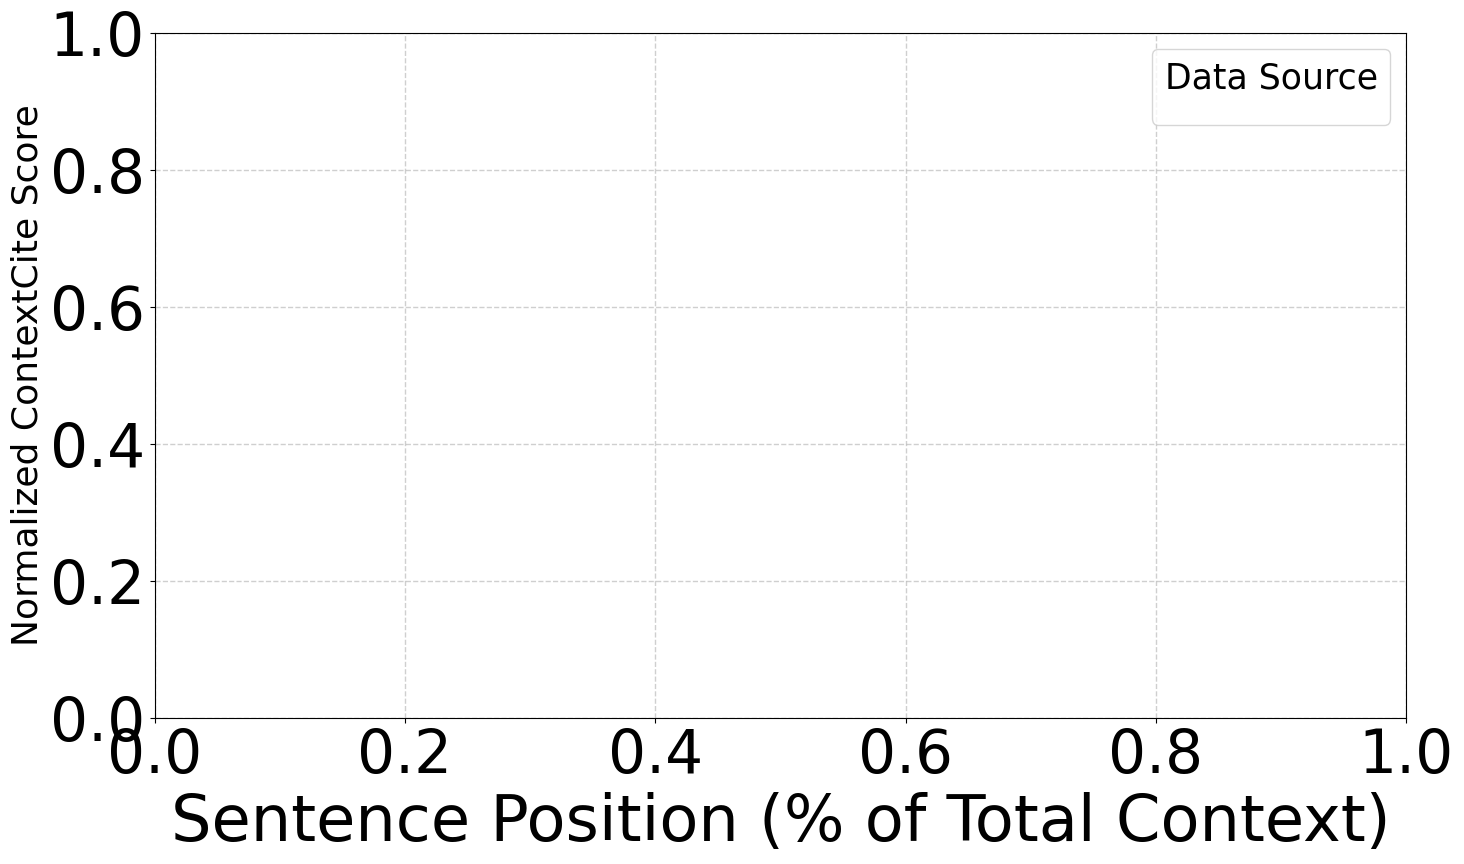

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Font styling
mpl.rcParams['font.size'] = 52
mpl.rcParams['axes.titlesize'] = 38
mpl.rcParams['axes.labelsize'] = 26
mpl.rcParams['xtick.labelsize'] = 23
mpl.rcParams['ytick.labelsize'] = 23
mpl.rcParams['legend.fontsize'] = 23
mpl.rcParams['legend.title_fontsize'] = 25
mpl.rcParams['figure.titlesize'] = 30

# ✅ Step 1: Drop invalid QA_IDs and coerce Score
df = df[~df["QA_ID"].astype(str).str.contains("ERROR", na=False)]
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

# ✅ Step 2: Normalize Score within each QA_ID
df["Score"] = df.groupby("QA_ID")["Score"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0
)

# ✅ Step 3: Add normalized position per sentence
df["position_pct"] = df.groupby("QA_ID").cumcount()
df["total_count"] = df.groupby("QA_ID")["Score"].transform("count")
df = df[df["total_count"] > 1]
df["position_pct"] = df["position_pct"] / (df["total_count"] - 1)

# ✅ Step 4: Clean up invalid source names
df = df[df["Source"].fillna('').str.strip() != "."]
df = df[df["Source"].notna()]

# ✅ Step 5: Plot
plt.figure(figsize=(16, 10))
window_size = 55
colors = ["#2196F3", "#f5a525", "#9C27B0", "#4CAF50"]

sources = sorted(df["Source"].dropna().unique())
for i, source in enumerate(sources):
    subset = df[df["Source"] == source]

    mean_score = subset.groupby("position_pct")["Score"].mean()
    std_score = subset.groupby("position_pct")["Score"].std()

    mean_smooth = mean_score.rolling(window=window_size, center=True, min_periods=1).mean()
    std_smooth = std_score.rolling(window=window_size, center=True, min_periods=1).mean()

    valid_idx = mean_smooth.notna() & std_smooth.notna()
    x = mean_smooth[valid_idx].index.values
    y = mean_smooth[valid_idx].values
    err = std_smooth[valid_idx].values

    plt.plot(x, y, color=colors[i % len(colors)], linewidth=5, label=source)
    y_lower = (y - err).clip(0, 1)
    y_upper = (y + err).clip(0, 1)
    plt.fill_between(x, y_lower, y_upper, color=colors[i % len(colors)], alpha=0.2)

# ✅ Step 6: Aesthetic Settings
plt.xlabel("Sentence Position (% of Total Context)", fontsize=46)
plt.ylabel("Normalized ContextCite Score", fontsize=26)
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.tick_params(labelsize=43)
plt.legend(title="Data Source", fontsize=23, title_fontsize=25)

plt.tight_layout()
plt.savefig("Attribution_Score_All_Sources_Combined.pdf", format="pdf", dpi=300)
plt.show()


## Compare 70B sentences w/ Human sentences

In [8]:
import pandas as pd
import re

# 1. Merge in the step1_sentences column as before
sent_labels = pd.read_csv("Sentence_Label_Original_2k.csv")
merged = grouped_stats.merge(
    sent_labels[['ID', 'step1_sentences']],
    left_on='Origin',
    right_on='ID',
    how='left'
)

# 2. Define a function to extract and filter sentence numbers
def extract_72B_ids(row):
    context = row['context']
    step1   = row.get('step1_sentences', '')
    # Find all numbered sentences in the reference string
    pairs = re.findall(r'(\d+)\.\s*([^\.]+?)(?=\.|$)', str(step1))
    filtered = []
    for num_str, sentence in pairs:
        num = int(num_str)
        # only keep if 1 <= num <= 21 and sentence text appears in context
        if 1 <= num <= 21 and sentence.strip() in context:
            filtered.append(num)
    # Sort and format as "1. 2. 4. 5."
    filtered.sort()
    return ' '.join(f'{n}.' for n in filtered)

# 3. Apply and rebuild your final DataFrame
merged['70B_sentence_ids'] = merged.apply(extract_70B_ids, axis=1)
grouped_stats = merged.drop(columns=['ID', 'step1_sentences']).reset_index(drop=True)
grouped_stats


KeyError: 'Origin'

In [1]:
import pandas as pd
import os

# Change directory to the location of the file
# os.chdir("/data/healthy-ml/scratch/yuexing/NeuRIPS25/Merge/Merge Attribution Scores Qwen72B/")

# Read the already combined file
df = pd.read_csv("attributions_summary_combined.csv") #, on_bad_lines='skip'

print(df.columns.tolist())

# Create the new column 'Centaur' in df with default value False
df['Centaur'] = False

physicians = pd.read_csv("Physician_Selected_Sentence_IDs.csv")

# Add this after reading the physicians CSV
print("Columns in physicians DataFrame:", physicians.columns.tolist())

## Sentence Number Matching
sentence_ID_Match = pd.read_csv("Sentence_Label_Original_2k.csv")

# First, sort the dataframe by QA_ID and Score (descending)
df_sorted = df.sort_values(['QA_ID', 'Score'], ascending=[True, False])

# Create a list to store the results
result_data = []

# Get the unique QA_IDs
unique_qa_ids = df_sorted['QA_ID'].unique()

# For each QA_ID
for qa_id in unique_qa_ids:
    # Get rows with this QA_ID
    qa_rows = df_sorted[df_sorted['QA_ID'] == qa_id]
    
    # Get the first Extracted_Answer (should be the same for all rows with this QA_ID)
    extracted_answer = qa_rows['Extracted_Answer'].iloc[0]
    
    # Convert each Source value to string before joining
    source_strings = [str(source) for source in qa_rows['Source']]
    merged_source = ' '.join(source_strings)
    
    # Add to result data
    result_data.append({
        'QA_ID': qa_id,
        'Extracted_Answer': extracted_answer,
        'merged_Source': merged_source
    })

# Create the new dataframe
Qwen_72B_Sentence_Selection = pd.DataFrame(result_data)

# Display the first few rows to verify
print(Qwen_72B_Sentence_Selection.head())

# Save to CSV if needed
Qwen_72B_Sentence_Selection.to_csv("Qwen_72B_Sentence_Selection.csv", index=False)

# First load the sentence_ID_Match dataframe (adjust path if needed)
sentence_ID_Match = pd.read_csv("Sentence_Label_Original_2k.csv")

# Function to find matching sentence column
def find_matching_sentence(source, row):
    source_str = str(source).lower()  # Convert to lowercase string for better matching
    
    # Check each sentence column
    for i in range(1, 22):  # Assuming columns are named sentence_1 through sentence_21
        col_name = f"sentence_{i}"
        if col_name in row:
            sentence_value = str(row[col_name]).lower()
            
            # Check if source is contained in the sentence or vice versa
            # This handles cases like "ddd" matching with "6. ddd"
            if source_str in sentence_value or sentence_value in source_str:
                return col_name
    
    # Return None if no match found
    return None


# Print columns before merge to verify
print("Columns in sentence_ID_Match:", sentence_ID_Match.columns.tolist())
print("Columns in physicians:", physicians.columns.tolist())

# Merge dataframes
merged_sentence_physician = pd.merge(
    sentence_ID_Match, 
    physicians,
    left_on="ID",
    right_on="Origin",
    how="left"  # Keep all rows from sentence_ID_Match
)

# Display the first few rows to verify
print(merged_sentence_physician.head())

# Count how many matches we got
match_count = merged_sentence_physician.dropna(subset=["Origin"]).shape[0]
print(f"Found {match_count} matches between sentence_ID_Match and physicians")

# Save to CSV if needed
merged_sentence_physician.to_csv("Merged_Sentence_Physician.csv", index=False)


# Apply the function row by row
df['sentence number'] = None  # Initialize new column

# We need to merge df with sentence_ID_Match first to have all columns available
# Update to use the correct column names for the merge
merged_df = pd.merge(
    df, 
    physicians, 
    left_on='QA_ID',  # Column name in df
    right_on='4k_ID',  # Column name in sentence_ID_Match
    how='left'
)

# Now we can check for matches
for idx, row in merged_df.iterrows():
    df.at[idx, 'sentence number'] = find_matching_sentence(row['Source'], row)

# Show the first few rows to verify
print(df[['QA_ID', 'Score','Source', 'sentence number']].head(30))

print("Columns in sentence_ID_Match:", sentence_ID_Match.columns.tolist())

# Before filtering
print(f"Number of rows before filtering: {len(df)}")

# Filter out rows where Source is only a period
df = df[~(df['Source'] == '.')]

# After filtering
print(f"Number of rows after filtering: {len(df)}")

# Show a sample of the filtered DataFrame to verify
print(df[['QA_ID', 'Score', 'Source', 'sentence number']].head(10))

# Initialize the new column with False
df['Select_Physicians?'] = False

# First, create a mapping from QA_ID to keep_k from the physicians DataFrame
keep_k_mapping = {}
for idx, row in physicians.iterrows():
    if '4k_ID' in row and not pd.isna(row['4k_ID']) and 'keep_k' in row:
        keep_k_mapping[row['4k_ID']] = int(row['keep_k'])

# For each QA_ID in df
for qa_id in df['QA_ID'].unique():
    # Skip if this QA_ID is not in our mapping
    if qa_id not in keep_k_mapping:
        continue
    
    # Get the keep_k value for this QA_ID
    k = keep_k_mapping[qa_id]
    
    # Get all rows with this QA_ID and sort by Score in descending order
    indices = df[df['QA_ID'] == qa_id].sort_values('Score', ascending=False).head(k).index
    
    # Mark the top k rows as True
    df.loc[indices, 'Select_Physicians?'] = True

# Check the results
print(f"Total rows marked as selected by physicians: {df['Select_Physicians?'].sum()}")
print("Sample of selected rows:")
print(df[df['Select_Physicians?'] == True][['QA_ID', 'Score', 'Source', 'sentence number', 'Select_Physicians?']].head(10))

# Add a column to show the keep_k value for each QA_ID
df['Physician_keep_k'] = df['QA_ID'].map(keep_k_mapping)

# Show sample rows with the new column included
print("Sample rows with keep_k values:")
print(df[['QA_ID', 'Score', 'Source', 'Physician_keep_k', 'Select_Physicians?']].head(20))

# Show sample of selected rows with keep_k values
print("\nSelected rows with keep_k values:")
print(df[df['Select_Physicians?'] == True][['QA_ID', 'Score', 'Source', 'Physician_keep_k', 'sentence number', 'Select_Physicians?']].head(10))

# Calculate some statistics about the keep_k values
if len(keep_k_mapping) > 0:
    print(f"\nAverage keep_k value: {sum(keep_k_mapping.values()) / len(keep_k_mapping)}")
    print(f"Min keep_k value: {min(keep_k_mapping.values())}")
    print(f"Max keep_k value: {max(keep_k_mapping.values())}")
    print(f"Most common keep_k value: {pd.Series(list(keep_k_mapping.values())).value_counts().index[0]}")

# Create a dictionary to store sentence numbers for each QA_ID
sentence_mapping = {}

# Loop through the df dataframe
for qa_id in df['QA_ID'].unique():
    # Find all rows where Select_Physicians? is True for this QA_ID
    selected_rows = df[(df['QA_ID'] == qa_id) & (df['Select_Physicians?'] == True)]
    
    if len(selected_rows) > 0:
        # Extract the sentence numbers
        sentence_numbers = []
        for sentence in selected_rows['sentence number'].dropna():
            # Extract just the number from strings like "sentence_5"
            if isinstance(sentence, str) and 'sentence_' in sentence:
                num = sentence.replace('sentence_', '')
                try:
                    sentence_numbers.append(int(num))
                except ValueError:
                    continue
        
        # Sort the numbers and join them with commas
        if sentence_numbers:
            sentence_numbers.sort()  # Sort from smallest to largest
            sentence_mapping[qa_id] = ','.join(map(str, sentence_numbers))

# Add the new column to physicians DataFrame
physicians['72B_Sentences'] = physicians['4k_ID'].map(sentence_mapping)

# Display results
print("Physicians DataFrame with 72B_Sentences column:")
print(physicians[['4k_ID', 'keep_k', 'human_sentence_ids', '72B_Sentences']].head(20))

# Save the updated physicians DataFrame to CSV
physicians.to_csv("Physician_Selected_Sentence_IDs_Updated.csv", index=False)

# Create a dictionary to store merged Source content for each QA_ID
source_content_mapping = {}

# Loop through the df dataframe
for qa_id in df['QA_ID'].unique():
    # Find all rows where Select_Physicians? is True for this QA_ID
    selected_rows = df[(df['QA_ID'] == qa_id) & (df['Select_Physicians?'] == True)]
    
    if len(selected_rows) > 0:
        # Extract the Source contents and join them
        sources = selected_rows['Source'].dropna().astype(str).tolist()
        if sources:
            source_content_mapping[qa_id] = ' | '.join(sources)

# Add the new column to physicians DataFrame
physicians['72B_Sentence_Contents'] = physicians['4k_ID'].map(source_content_mapping)

# Display results
print("Physicians DataFrame with 72B_Sentence_Contents column:")
print(physicians[['4k_ID', 'keep_k', '72B_Sentences', '72B_Sentence_Contents']].head(10))

# Save the updated physicians DataFrame to CSV
physicians.to_csv("Physician_Selected_Sentence_IDs_Updated.csv", index=False)

# Function to calculate match rate between two comma-separated number strings
def calculate_match_rate(human_ids, model_ids):
    if pd.isna(human_ids) or pd.isna(model_ids) or human_ids == '' or model_ids == '':
        return 0.0
    
    # Convert comma-separated strings to sets of integers
    try:
        human_set = set(int(x.strip()) for x in str(human_ids).split(','))
        model_set = set(int(x.strip()) for x in str(model_ids).split(','))
    except:
        return 0.0
    
    # If either set is empty, return 0
    if not human_set or not model_set:
        return 0.0
    
    # Calculate intersection and union
    intersection = human_set.intersection(model_set)
    union = human_set.union(model_set)
    
    # Calculate match rate
    return len(intersection) / len(union)

# Apply the function to calculate match rate for each row
physicians['match_rate'] = physicians.apply(
    lambda row: calculate_match_rate(row['human_sentence_ids'], row['72B_Sentences']), 
    axis=1
)

# Overall statistics
print("===== Overall Match Rate Statistics =====")
print(f"Mean match rate: {physicians['match_rate'].mean():.4f}")
print(f"Median match rate: {physicians['match_rate'].median():.4f}")
print(f"Min match rate: {physicians['match_rate'].min():.4f}")
print(f"Max match rate: {physicians['match_rate'].max():.4f}")
print(f"Standard deviation: {physicians['match_rate'].std():.4f}")
print(f"Total rows with data: {physicians['match_rate'].count()}")
print(f"Rows with exact matches (rate=1.0): {(physicians['match_rate'] == 1.0).sum()}")
print(f"Rows with no matches (rate=0.0): {(physicians['match_rate'] == 0.0).sum()}")

# Statistics by data_source
if 'data_source_corr' in physicians.columns:
    print("\n===== Match Rate by Data Source =====")
    datasource_stats = physicians.groupby('data_source_corr')['match_rate'].agg(['mean', 'median', 'min', 'max', 'std', 'count'])
    datasource_stats = datasource_stats.sort_values('mean', ascending=False)
    print(datasource_stats)
    
    # Count of exact and zero matches by data_source
    print("\nExact matches by data source:")
    print(physicians[physicians['match_rate'] == 1.0]['data_source_corr'].value_counts())
    
    print("\nZero matches by data source:")
    print(physicians[physicians['match_rate'] == 0.0]['data_source_corr'].value_counts())
else:
    print("\nColumn 'data_source_corr' not found in the DataFrame")

# Save the updated DataFrame with match rates
physicians.to_csv("Physician_Selected_Sentence_IDs_With_Match_Rates.csv", index=False)

# # Visualize the distribution of match rates
# try:
#     import matplotlib.pyplot as plt
    
#     plt.figure(figsize=(10, 6))
#     plt.hist(physicians['match_rate'], bins=20, alpha=0.7, color='blue', edgecolor='black')
#     plt.title('Distribution of Match Rates Between Human and 72B Model Selections')
#     plt.xlabel('Match Rate')
#     plt.ylabel('Frequency')
#     plt.grid(True, alpha=0.3)
#     plt.savefig('match_rate_distribution.png')
#     print("\nMatch rate distribution saved as 'match_rate_distribution.png'")
# except Exception as e:
#     print(f"\nCouldn't create visualization: {str(e)}")

# # Add after line 75 (after the find_matching_sentence function)
# print("Sample merged_df rows:")
# print(merged_df[['QA_ID', 'Source', '4k_ID']].head())
# print(f"Number of matches in merged_df: {len(merged_df.dropna(subset=['4k_ID']))}")

# # Add after line 158 (after creating sentence_mapping)
# print("QA_IDs with sentence mappings:", list(sentence_mapping.keys())[:10])
# print("Sample sentence mappings:", {k: sentence_mapping[k] for k in list(sentence_mapping.keys())[:5]})
# print("Number of QA_IDs with sentence mappings:", len(sentence_mapping))

# # Add a check of filename format in the file reading loop (around line 12)
# print("Sample filenames from 14B folder:", [f for f in os.listdir(input_folder) if f.endswith(".csv")][:5])

['Score', 'Source', 'QA_ID', 'Extracted_Answer', 'Raw_Response']
Columns in physicians DataFrame: ['Origin', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12', 'q13', 'q14', 'q15', 'q16', 'q17', 'q18', 'q19', 'q20', 'q21', 'ID_corr', 'centaur_question_corr', 'sentence_number_corr', 'answer_corr', 'data_source_corr', 'Match', 'REMOVED_Sentences', 'ID_df3', 'centaur_question_df3', 'sentence_number_df3', 'answer_df3', 'data_source_df3', 'step1_excerpts', 'question_options', 'step1_sentences', 'sentence_1', 'sentence_2', 'sentence_3', 'sentence_4', 'sentence_5', 'sentence_6', 'sentence_7', 'sentence_8', 'sentence_9', 'sentence_10', 'sentence_11', 'sentence_12', 'sentence_13', 'sentence_14', 'sentence_15', 'sentence_16', 'sentence_17', 'sentence_18', 'sentence_19', 'sentence_20', 'sentence_21', 'word_count', 'number_count', 'Filtered_Sentences', 'New_Sentences', '4k_ID', 'human_sentence_ids', 'keep_k']
                                               QA_ID Extracted_Answer  

Total rows marked as selected by physicians: 6969
Sample of selected rows:
       QA_ID             Score  \
0   Merge Q1  16.4903377201195   
1   Merge Q1  7.76135006235185   
2   Merge Q1               0.0   
6   Merge Q1  -5.2588287964042   
20  Merge Q3  9.49253752188175   
21  Merge Q3  5.27593078029905   
22  Merge Q3  4.85133605315447   
23  Merge Q3  3.34548899531364   
24  Merge Q3   1.6228544789055   
38  Merge Q4   7.4976530642572   

                                               Source sentence number  \
0   A man in his 30s with AIDS presented with acut...      sentence_1   
1   These contents were placed on a glass slide, f...      sentence_5   
2   The patient also had a new-onset cough but was...      sentence_2   
6   B, Tzanck smear using Wright-Giemsa staining o...      sentence_6   
20  C, PET/CT 12 weeks after treatment initiation....            None   
21  Complete blood cell count and peripheral blood...      sentence_6   
22  Bone marrow biopsy showed hypercell

===== Overall Match Rate Statistics =====
Mean match rate: 0.4499
Median match rate: 0.4444
Min match rate: 0.0000
Max match rate: 1.0000
Standard deviation: 0.2672
Total rows with data: 1300
Rows with exact matches (rate=1.0): 100
Rows with no matches (rate=0.0): 132

===== Match Rate by Data Source =====
                      mean    median  min  max       std  count
data_source_corr                                               
medxpert          0.518021  0.500000  0.0  1.0  0.303264    318
medbullets        0.497854  0.500000  0.0  1.0  0.247572    207
jama              0.455478  0.449495  0.0  1.0  0.239008    582
mmlu              0.269263  0.300000  0.0  1.0  0.222265    193

Exact matches by data source:
medxpert      60
jama          20
medbullets    18
mmlu           2
Name: data_source_corr, dtype: int64

Zero matches by data source:
mmlu          57
jama          33
medxpert      30
medbullets    12
Name: data_source_corr, dtype: int64
